# Data Loader

TensorFlow Data Loader for U-Net
TensorFlow version: 2.13.0
Found 277472 image patches
Found 36800 image patches

Dataset Configuration:
  Training patches: 277472
  Validation patches: 36800
  Batch size: 8
  Steps per epoch (train): 34684
  Steps per epoch (val): 4600

Visualizing sample batches...

Training batch (with augmentation):


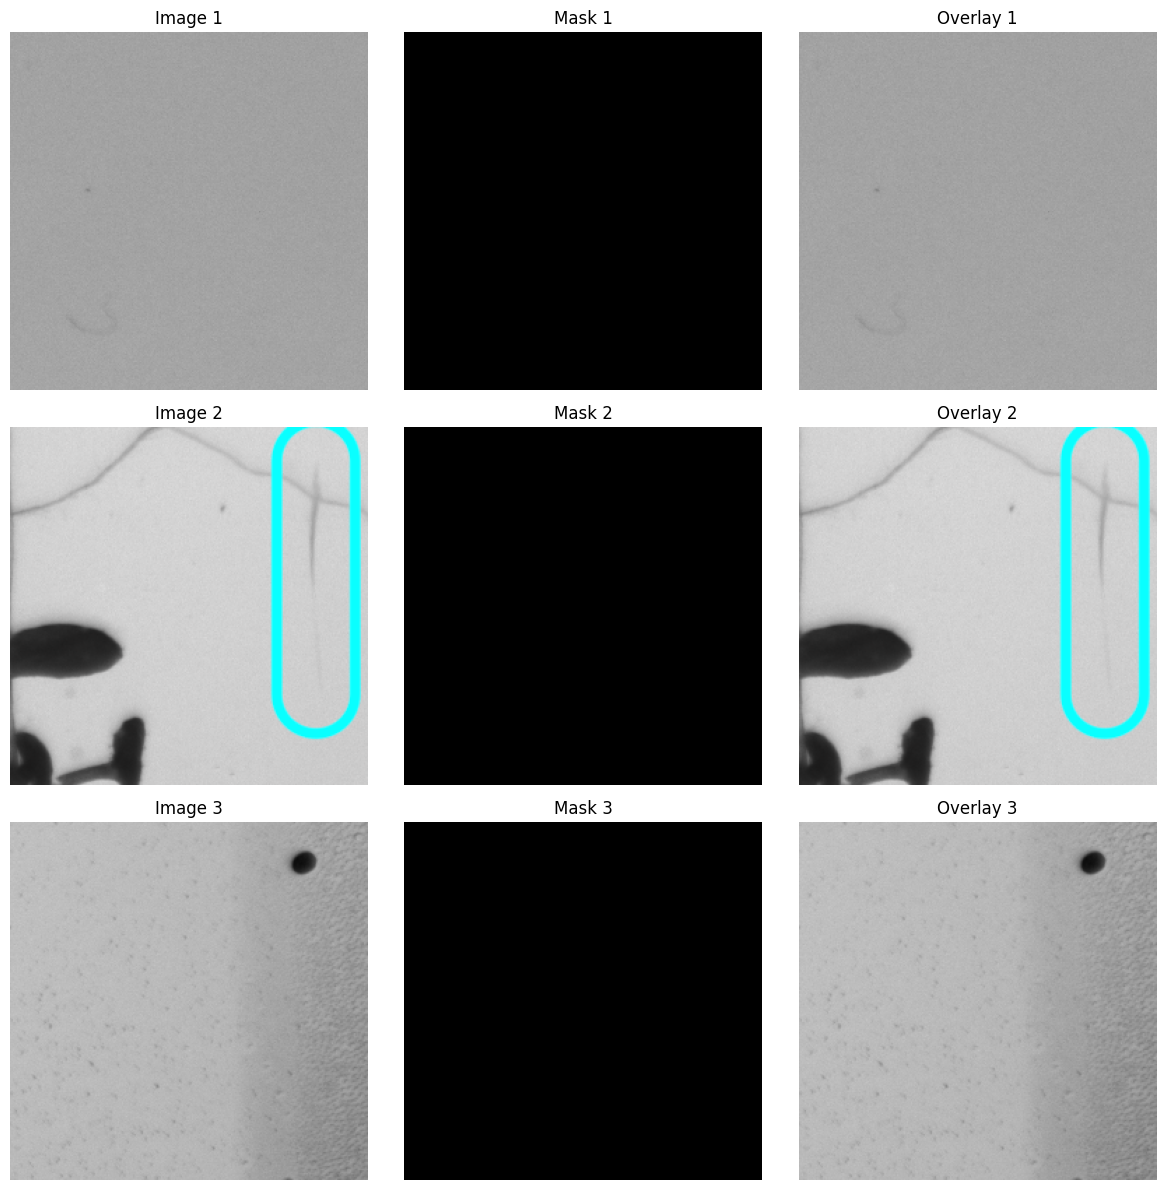


Validation batch (no augmentation):


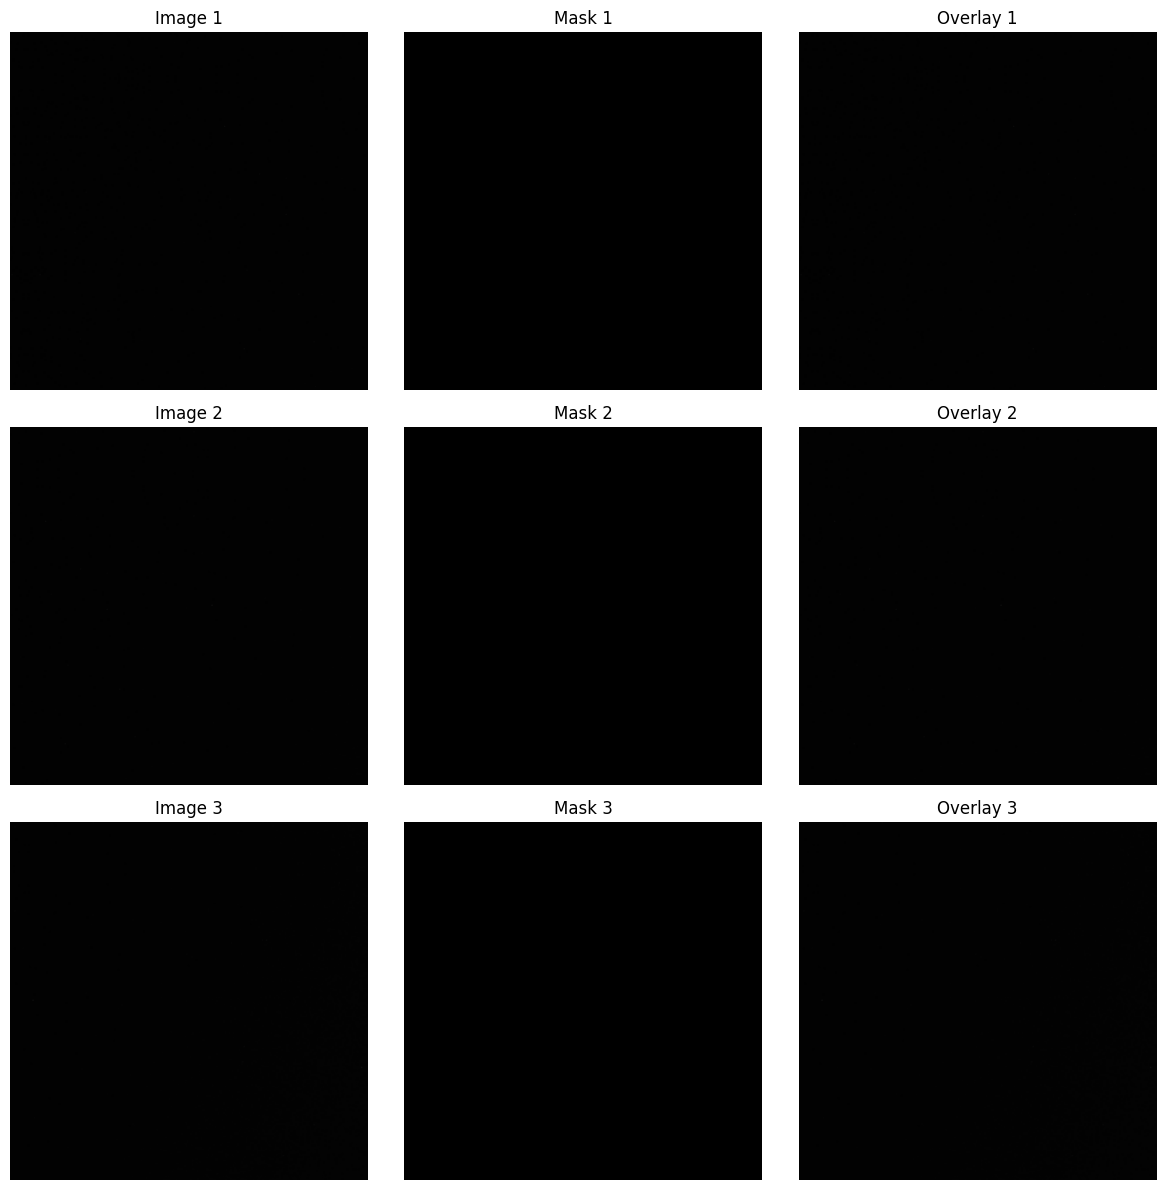


Data loaders ready for training!


# Model

In [3]:
"""
U-Net Model for Plant Root Segmentation

Architecture choice rationale:
- Classic U-Net: Proven effective for root segmentation (Smith et al. 2020)
- Input: 256x256 RGB images
- Output: Binary segmentation (root vs background)
- No transfer learning: U-Net works well from scratch for this task
- Lightweight: ~31M parameters, suitable for local training

Alternative approaches if this doesn't work well:
1. Add ImageNet pre-trained encoder (EfficientNetB0) for transfer learning
2. Switch to ResU-Net (adds residual blocks for better gradient flow)
3. Try Dice loss instead of BCE if class imbalance is severe
"""

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


# ============================================================================
# U-NET ARCHITECTURE
# ============================================================================

def conv_block(inputs, num_filters, dropout_rate=0.1):
    """
    Convolutional block: Conv2D -> BatchNorm -> ReLU -> Conv2D -> BatchNorm -> ReLU
    
    Why this design:
    - Double convolution is standard U-Net design
    - BatchNorm helps with training stability
    - Dropout prevents overfitting (important for small datasets)
    """
    x = layers.Conv2D(num_filters, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)
    
    return x


def encoder_block(inputs, num_filters, dropout_rate=0.1):
    """
    Encoder block: conv_block -> MaxPooling
    
    Returns both the output for next layer and skip connection
    """
    x = conv_block(inputs, num_filters, dropout_rate)
    p = layers.MaxPooling2D((2, 2))(x)
    return x, p


def decoder_block(inputs, skip_features, num_filters, dropout_rate=0.1):
    """
    Decoder block: UpSampling -> Concatenate with skip -> conv_block
    
    Why concatenate instead of add:
    - U-Net uses concatenation to preserve both low and high-level features
    - Critical for precise segmentation boundaries
    """
    x = layers.Conv2DTranspose(num_filters, 2, strides=2, padding='same')(inputs)
    x = layers.concatenate([x, skip_features])
    x = conv_block(x, num_filters, dropout_rate)
    return x


def build_unet(input_shape=(256, 256, 3), num_filters=64, dropout_rate=0.1):
    """
    Build classic U-Net architecture.
    
    Args:
        input_shape: Input image shape (height, width, channels)
        num_filters: Base number of filters (doubles at each level)
        dropout_rate: Dropout rate for regularization
        
    Returns:
        Keras Model
        
    Architecture:
    - 4 encoder levels: 64 -> 128 -> 256 -> 512 filters
    - Bottleneck: 1024 filters
    - 4 decoder levels: 512 -> 256 -> 128 -> 64 filters
    - Output: Single channel with sigmoid activation (binary segmentation)
    
    Why these choices:
    - 4 levels: Standard for 256x256 images (final spatial size: 16x16)
    - Filter progression: Standard U-Net design
    - Sigmoid output: Binary segmentation (0=background, 1=root)
    """
    inputs = layers.Input(input_shape)
    
    # Encoder
    s1, p1 = encoder_block(inputs, num_filters, dropout_rate)      # 256x256 -> 128x128
    s2, p2 = encoder_block(p1, num_filters*2, dropout_rate)        # 128x128 -> 64x64
    s3, p3 = encoder_block(p2, num_filters*4, dropout_rate)        # 64x64 -> 32x32
    s4, p4 = encoder_block(p3, num_filters*8, dropout_rate)        # 32x32 -> 16x16
    
    # Bottleneck
    b = conv_block(p4, num_filters*16, dropout_rate)               # 16x16
    
    # Decoder
    d1 = decoder_block(b, s4, num_filters*8, dropout_rate)         # 16x16 -> 32x32
    d2 = decoder_block(d1, s3, num_filters*4, dropout_rate)        # 32x32 -> 64x64
    d3 = decoder_block(d2, s2, num_filters*2, dropout_rate)        # 64x64 -> 128x128
    d4 = decoder_block(d3, s1, num_filters, dropout_rate)          # 128x128 -> 256x256
    
    # Output
    outputs = layers.Conv2D(1, 1, padding='same', activation='sigmoid')(d4)
    
    model = keras.Model(inputs, outputs, name='U-Net')
    return model


# ============================================================================
# LOSS FUNCTIONS
# ============================================================================

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    """
    Dice coefficient metric (F1-score for segmentation).
    
    Range: 0 (no overlap) to 1 (perfect overlap)
    Why: Standard metric for segmentation evaluation
    """
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    """
    Dice loss = 1 - Dice coefficient.
    
    Why use Dice loss:
    - Works better than BCE for imbalanced segmentation
    - Directly optimizes the evaluation metric
    - More robust to class imbalance (root vs background)
    
    Alternative: Use BCE if you have balanced classes
    """
    return 1 - dice_coefficient(y_true, y_pred)


def combined_loss(y_true, y_pred):
    """
    Combined Binary Cross-Entropy + Dice Loss.
    
    Why combine:
    - BCE helps with pixel-level accuracy
    - Dice loss helps with region-level overlap
    - Together they work better than either alone
    
    Weights: 0.5 BCE + 0.5 Dice (adjust if needed)
    """
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return 0.5 * bce + 0.5 * dice_loss(y_true, y_pred)


def iou_metric(y_true, y_pred, threshold=0.5):
    """
    Intersection over Union (IoU) metric.
    
    Also called Jaccard index. Standard segmentation metric.
    """
    y_pred_binary = tf.cast(y_pred > threshold, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred_binary)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_binary) - intersection
    return (intersection + 1e-6) / (union + 1e-6)


# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

def create_callbacks(output_dir, patience=15):
    """
    Create training callbacks.
    
    Args:
        output_dir: Directory to save checkpoints and logs
        patience: Number of epochs to wait for improvement
        
    Callbacks:
    - ModelCheckpoint: Save best model based on validation Dice
    - EarlyStopping: Stop if validation doesn't improve
    - ReduceLROnPlateau: Reduce learning rate when plateau
    - TensorBoard: Visualize training progress
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    callbacks = [
        # Save best model
        keras.callbacks.ModelCheckpoint(
            filepath=str(output_dir / 'best_model.h5'),
            monitor='val_dice_coefficient',
            mode='max',
            save_best_only=True,
            verbose=1
        ),
        
        # Early stopping
        keras.callbacks.EarlyStopping(
            monitor='val_dice_coefficient',
            mode='max',
            patience=patience,
            verbose=1,
            restore_best_weights=True
        ),
        
        # Reduce learning rate on plateau
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        ),
        
        # TensorBoard logging
        keras.callbacks.TensorBoard(
            log_dir=str(output_dir / 'logs'),
            histogram_freq=0,
            write_graph=False
        ),
        
        # Save training history
        keras.callbacks.CSVLogger(
            str(output_dir / 'training_history.csv')
        )
    ]
    
    return callbacks


# ============================================================================
# VISUALIZATION
# ============================================================================

def visualize_predictions(model, dataset, num_samples=5, save_path=None):
    """
    Visualize model predictions on validation samples.
    """
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    for i, (images, masks) in enumerate(dataset.take(num_samples)):
        if i >= num_samples:
            break
            
        # Get first image from batch
        image = images[0].numpy()
        mask = masks[0].numpy()
        
        # Predict
        pred = model.predict(images[0:1], verbose=0)[0]
        pred_binary = (pred > 0.5).astype(np.float32)
        
        # Calculate metrics
        dice = dice_coefficient(mask, pred).numpy()
        iou = iou_metric(mask, pred).numpy()
        
        # Plot
        if num_samples == 1:
            ax = axes
        else:
            ax = axes[i]
            
        # Original image
        ax[0].imshow(image)
        ax[0].set_title('Input Image')
        ax[0].axis('off')
        
        # Ground truth mask
        ax[1].imshow(mask[:, :, 0], cmap='gray', vmin=0, vmax=1)
        ax[1].set_title('Ground Truth')
        ax[1].axis('off')
        
        # Prediction
        ax[2].imshow(pred[:, :, 0], cmap='gray', vmin=0, vmax=1)
        ax[2].set_title(f'Prediction\nDice: {dice:.3f}, IoU: {iou:.3f}')
        ax[2].axis('off')
        
        # Overlay
        overlay = image.copy()
        root_pixels = pred_binary[:, :, 0] > 0.5
        overlay[root_pixels] = [0, 1, 0]  # Green for predicted roots
        blended = 0.6 * image + 0.4 * overlay
        ax[3].imshow(blended)
        ax[3].set_title('Overlay')
        ax[3].axis('off')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Visualization saved to {save_path}")
    
    plt.show()


def plot_training_history(history_path, save_path=None):
    """
    Plot training history from CSV file.
    """
    import pandas as pd
    
    df = pd.read_csv(history_path)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Loss
    axes[0].plot(df['epoch'], df['loss'], label='Train Loss')
    axes[0].plot(df['epoch'], df['val_loss'], label='Val Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Dice coefficient
    axes[1].plot(df['epoch'], df['dice_coefficient'], label='Train Dice')
    axes[1].plot(df['epoch'], df['val_dice_coefficient'], label='Val Dice')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Dice Coefficient')
    axes[1].set_title('Dice Coefficient')
    axes[1].legend()
    axes[1].grid(True)
    
    # IoU
    axes[2].plot(df['epoch'], df['iou_metric'], label='Train IoU')
    axes[2].plot(df['epoch'], df['val_iou_metric'], label='Val IoU')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('IoU')
    axes[2].set_title('IoU Metric')
    axes[2].legend()
    axes[2].grid(True)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    
    plt.show()


# ============================================================================
# MAIN TRAINING SCRIPT
# ============================================================================

def main():
    """
    Main training function.
    """
    print("="*70)
    print("U-Net Training for Plant Root Segmentation")
    print("="*70)
    
    # Configuration
    PATCHES_BASE = Path("../data/processed/dataset_24_patches_fixed")
    OUTPUT_DIR = Path("../models/unet_root_segmentation")
    
    BATCH_SIZE = 8          # Adjust based on your GPU memory
    EPOCHS = 100            # Will stop early if no improvement
    LEARNING_RATE = 1e-4    # Good starting point for Adam
    NUM_FILTERS = 64        # Base number of filters (standard)
    DROPOUT_RATE = 0.15     # Regularization to prevent overfitting
    
    print("\nConfiguration:")
    print(f"  Batch size: {BATCH_SIZE}")
    print(f"  Max epochs: {EPOCHS}")
    print(f"  Learning rate: {LEARNING_RATE}")
    print(f"  Base filters: {NUM_FILTERS}")
    print(f"  Dropout rate: {DROPOUT_RATE}")
    print(f"  Output directory: {OUTPUT_DIR}")
    
    # Check TensorFlow GPU availability
    print(f"\nTensorFlow version: {tf.__version__}")
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"GPUs available: {len(gpus)}")
        for gpu in gpus:
            print(f"  - {gpu}")
    else:
        print("No GPU detected - training will use CPU (slower)")
    
    # Load data
    print("\n" + "="*70)
    print("Loading datasets...")
    print("="*70)
    
    from train import create_data_loaders  # Import your dataloader
    
    train_dataset, val_dataset, train_steps, val_steps = create_data_loaders(
        train_images_dir=str(PATCHES_BASE / "train_images"),
        train_masks_dir=str(PATCHES_BASE / "train_masks"),
        val_images_dir=str(PATCHES_BASE / "val_images"),
        val_masks_dir=str(PATCHES_BASE / "val_masks"),
        batch_size=BATCH_SIZE,
        augment_train=True
    )
    
    # Build model
    print("\n" + "="*70)
    print("Building U-Net model...")
    print("="*70)
    
    model = build_unet(
        input_shape=(256, 256, 3),
        num_filters=NUM_FILTERS,
        dropout_rate=DROPOUT_RATE
    )
    
    # Print model summary
    model.summary()
    
    # Count parameters
    trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    print(f"\nTotal trainable parameters: {trainable_params:,}")
    
    # Compile model
    print("\nCompiling model...")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss=combined_loss,
        metrics=[
            dice_coefficient,
            iou_metric,
            'binary_accuracy'
        ]
    )
    
    # Create callbacks
    callbacks = create_callbacks(OUTPUT_DIR, patience=15)
    
    # Train model
    print("\n" + "="*70)
    print("Starting training...")
    print("="*70)
    
    history = model.fit(
        train_dataset,
        steps_per_epoch=train_steps,
        validation_data=val_dataset,
        validation_steps=val_steps,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )
    
    # Save final model
    print("\n" + "="*70)
    print("Training complete!")
    print("="*70)
    
    final_model_path = OUTPUT_DIR / 'final_model.h5'
    model.save(final_model_path)
    print(f"\nFinal model saved to: {final_model_path}")
    
    # Plot training history
    print("\nPlotting training history...")
    plot_training_history(
        OUTPUT_DIR / 'training_history.csv',
        save_path=OUTPUT_DIR / 'training_history.png'
    )
    
    # Visualize predictions
    print("\nVisualizing predictions on validation set...")
    visualize_predictions(
        model,
        val_dataset,
        num_samples=5,
        save_path=OUTPUT_DIR / 'validation_predictions.png'
    )
    
    print("\n" + "="*70)
    print("Training pipeline complete!")
    print("="*70)
    print(f"\nBest model: {OUTPUT_DIR / 'best_model.h5'}")
    print(f"Training history: {OUTPUT_DIR / 'training_history.csv'}")
    print(f"TensorBoard logs: {OUTPUT_DIR / 'logs'}")
    print("\nTo view training progress in TensorBoard, run:")
    print(f"  tensorboard --logdir {OUTPUT_DIR / 'logs'}")


if __name__ == "__main__":
    main()

U-Net Training for Plant Root Segmentation

Configuration:
  Batch size: 8
  Max epochs: 100
  Learning rate: 0.0001
  Base filters: 64
  Dropout rate: 0.15
  Output directory: ..\models\unet_root_segmentation

TensorFlow version: 2.13.0
No GPU detected - training will use CPU (slower)

Loading datasets...
Found 277472 image patches
Found 36800 image patches

Dataset Configuration:
  Training patches: 277472
  Validation patches: 36800
  Batch size: 8
  Steps per epoch (train): 34684
  Steps per epoch (val): 4600

Building U-Net model...
Model: "U-Net"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 256, 256,

KeyboardInterrupt: 